# Hybridizing an existing power plant

This example starts with an existing solar plant, adds wind in project year 5, and adds a battery in project year 8. The deployment year, operating lifetime, and technology-specific CAPEX phasing are supplied directly when `hpp_model` is instantiated and take precedence over any `technologies` entry in the simulation-parameter YAML file where the same information can also be conveyed.

## Imports

In [1]:
# Install hydesign if needed
import importlib
if not importlib.util.find_spec("hydesign"):
    !pip install git+https://gitlab.windenergy.dtu.dk/TOPFARM/hydesign.git

In [2]:
%matplotlib inline

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from hydesign.assembly.hpp_assembly import hpp_model
from hydesign.examples import examples_filepath

plt.style.use("seaborn-v0_8-whitegrid")

## Site and plant design

The YAML file still provides site, cost, degradation, and finance assumptions. The technology schedule is deliberately defined below in Python and passed to the constructor.

In [3]:
examples_sites = pd.read_csv(
    f"{examples_filepath}examples_sites.csv", index_col=0, sep=";"
)
site_name = "Denmark_hybridization_solar_Langelinie"
site = examples_sites.loc[examples_sites.name == site_name].iloc[0]

sim_pars_fn = examples_filepath + site.sim_pars_fn
input_ts_fn = examples_filepath + site.input_ts_fn

site[["name", "longitude", "latitude", "altitude", "sim_pars_fn"]]

name           Denmark_hybridization_solar_Langelinie
longitude                                   11.290641
latitude                                    54.717469
altitude                                        0.042
sim_pars_fn            Europe/hpp_pars_Langelinie.yml
Name: 13, dtype: object

In [4]:
design = dict(
    clearance=50,
    sp=301,
    p_rated=2,
    Nwt=3,
    wind_MW_per_km2=10,
    solar_MW=7.48,
    surface_tilt=25,
    surface_azimuth=180,
    DC_AC_ratio=1.32,
    b_P=10,
    b_E_h=3,
    cost_of_battery_P_fluct_in_peak_price_ratio=0,
)

## Define delayed deployment directly

CAPEX phasing years are relative to each technology's deployment year. Thus 25% of wind CAPEX is paid in project year 4 and 75% in year 5. Solar is present from year 0, wind changes the EMS in year 5, and the battery enables storage operation and arbitrage from year 8.

In [5]:
hybrid_schedule = [
    {
        "name": "solar",
        "deployment_year": 0,
        "lifetime": 25,
        "capex_phasing": {"years": [0], "shares": [1.0]},
    },
    {
        "name": "wind",
        "deployment_year": 5,
        "lifetime": 25,
        "capex_phasing": {"years": [-1, 0], "shares": [0.25, 0.75]},
    },
    {
        "name": "battery",
        "deployment_year": 8,
        "lifetime": 15,
        "capex_phasing": {"years": [0], "shares": [1.0]},
    },
]

all_at_once_schedule = [
    {"name": item["name"], "deployment_year": 0, "lifetime": item["lifetime"]}
    for item in hybrid_schedule
]

pd.DataFrame(hybrid_schedule).set_index("name")

,deployment_year,lifetime,capex_phasing
name,,,
solar,0,25,"{'years': [0], 'shares': [1.0]}"
wind,5,25,"{'years': [-1, 0], 'shares': [0.25, 0.75]}"
battery,8,15,"{'years': [0], 'shares': [1.0]}"


## Instantiate and evaluate both cases

Notice that `technologies=hybrid_schedule` is an explicit constructor argument. It overrides the schedule currently stored in `hpp_pars_Langelinie.yml`.

In [6]:
common_hpp_inputs = dict(
    latitude=site.latitude,
    longitude=site.longitude,
    altitude=site.altitude,
    max_num_batteries_allowed=10,
    work_dir="./",
    sim_pars_fn=sim_pars_fn,
    input_ts_fn=input_ts_fn,
    verbose=False,
)

hybrid_hpp = hpp_model(technologies=hybrid_schedule, **common_hpp_inputs)
baseline_hpp = hpp_model(technologies=all_at_once_schedule, **common_hpp_inputs)


In [7]:
start = time.time()
hybrid_outputs = hybrid_hpp.evaluate(**design)
baseline_outputs = baseline_hpp.evaluate(**design)
print(f"Two evaluations completed in {(time.time() - start) / 60:.2f} min")

summary_columns = [
    "NPV_over_CAPEX",
    "NPV [MEuro]",
    "IRR",
    "LCOE [Euro/MWh]",
    "Revenues [MEuro]",
    "CAPEX [MEuro]",
    "OPEX [MEuro]",
    "Mean Annual Electricity Sold [GWh]",
]
summary = pd.DataFrame(
    [hybrid_outputs, baseline_outputs],
    index=["staged hybridization", "all technologies in year 0"],
    columns=hybrid_hpp.list_out_vars,
)[summary_columns]
summary

Two evaluations completed in 2.37 min


,NPV_over_CAPEX,NPV [MEuro],IRR,LCOE [Euro/MWh],Revenues [MEuro],CAPEX [MEuro],OPEX [MEuro],Mean Annual Electricity Sold [GWh]
staged hybridization,0.271529,3.091229,0.073706,33.176412,0.880086,11.384512,0.143382,23.336857
all technologies in year 0,0.204377,2.477875,0.067362,34.341152,1.058023,12.124028,0.143382,27.999407


## Compile annual operating and finance vectors


In [8]:
HOURS_PER_YEAR = 365 * 24
TECH_COLORS = {
    "wind": "#2f6f9f",
    "solar": "#f2b134",
    "battery": "#7656a5",
    "shared": "#7f8c8d",
}


def compile_yearly_results(hpp):
    n_years = hpp.project_life_y
    prob = hpp.prob

    hpp_power = prob.get_val("hpp_t_with_deg").reshape(n_years, HOURS_PER_YEAR)
    price = prob.get_val("price_t_ext").reshape(n_years, HOURS_PER_YEAR)
    penalty = prob.get_val("penalty_t_with_deg").reshape(n_years, HOURS_PER_YEAR)
    battery_power = prob.get_val("b_t_with_deg").reshape(n_years, HOURS_PER_YEAR)

    capex = pd.DataFrame(
        {
            technology: prob.get_val(variable).ravel() / 1e6
            for technology, variable in {
                "wind": "CAPEX_w_vec",
                "solar": "CAPEX_s_vec",
                "battery": "CAPEX_b_vec",
                "shared": "CAPEX_sh_vec",
            }.items()
        },
        index=pd.Index(range(n_years + 1), name="project year"),
    )
    opex = pd.DataFrame(
        {
            technology: prob.get_val(variable).ravel() / 1e6
            for technology, variable in {
                "wind": "OPEX_w_vec",
                "solar": "OPEX_s_vec",
                "battery": "OPEX_b_vec",
                "shared": "OPEX_sh_vec",
            }.items()
        },
        index=pd.Index(range(n_years), name="operating year"),
    )

    annual = pd.DataFrame(index=opex.index)
    annual["revenue"] = (hpp_power * price - penalty).sum(axis=1) / 1e6
    annual["opex"] = opex.sum(axis=1)
    annual["capex"] = capex.sum(axis=1).iloc[:n_years].to_numpy()
    annual["cash_flow"] = annual.revenue - annual.opex - annual.capex
    annual["cumulative_cash_flow"] = annual.cash_flow.cumsum()
    annual["energy_sold_GWh"] = hpp_power.sum(axis=1) / 1e3
    annual["battery_throughput_GWh"] = np.abs(battery_power).sum(axis=1) / 2e3
    return capex, opex, annual


hybrid_capex, hybrid_opex, hybrid_annual = compile_yearly_results(hybrid_hpp)
baseline_capex, baseline_opex, baseline_annual = compile_yearly_results(baseline_hpp)

hybrid_finance_vectors = pd.concat(
    {"CAPEX [MEuro]": hybrid_capex, "OPEX [MEuro/year]": hybrid_opex},
    axis=1,
)


## Technology timeline

Each bar is the technology's operating window. The vertical lines are the two changes in the set of active technologies, so the EMS representative year is solved once for each of the three stages and then concatenated over its stage interval.

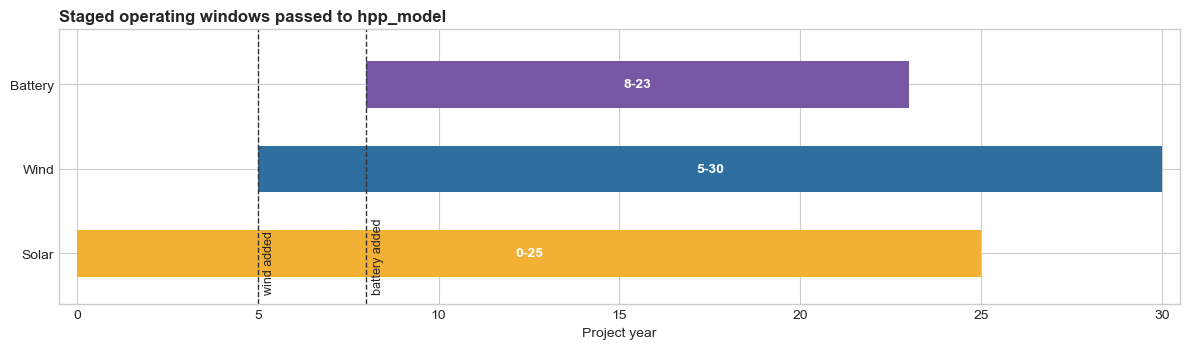

In [9]:
fig, ax = plt.subplots(figsize=(12, 3.6))
schedule_items = list(hybrid_hpp.technology_schedule.items())
for row, (technology, values) in enumerate(schedule_items):
    start = values["deployment_year"]
    lifetime = values["lifetime"]
    ax.barh(
        row, lifetime, left=start, height=0.55,
        color=TECH_COLORS[technology], label=technology.title(),
    )
    ax.text(start + lifetime / 2, row, f"{start}-{start + lifetime}",
            ha="center", va="center", color="white", fontweight="bold")

for year, label in [(5, "wind added"), (8, "battery added")]:
    ax.axvline(year, color="#333333", linestyle="--", linewidth=1)
    ax.text(year + 0.15, -0.48, label, rotation=90, va="bottom", fontsize=9)

ax.set(yticks=range(len(schedule_items)), yticklabels=[name.title() for name, _ in schedule_items])
ax.set_xlabel("Project year")
ax.set_title("Staged operating windows passed to hpp_model", loc="left", fontweight="bold")
ax.set_xlim(-0.5, hybrid_hpp.project_life_y + 0.5)
ax.set_ylim(-0.6, len(schedule_items) - 0.35)
plt.tight_layout()
plt.show()

## CAPEX, OPEX, revenue, and cash flow

The staged case has several investment events instead of one year-0 CAPEX spike. OPEX starts and stops with each technology's operating window. Shared CAPEX can appear again when an add-on increases the required shared footprint.

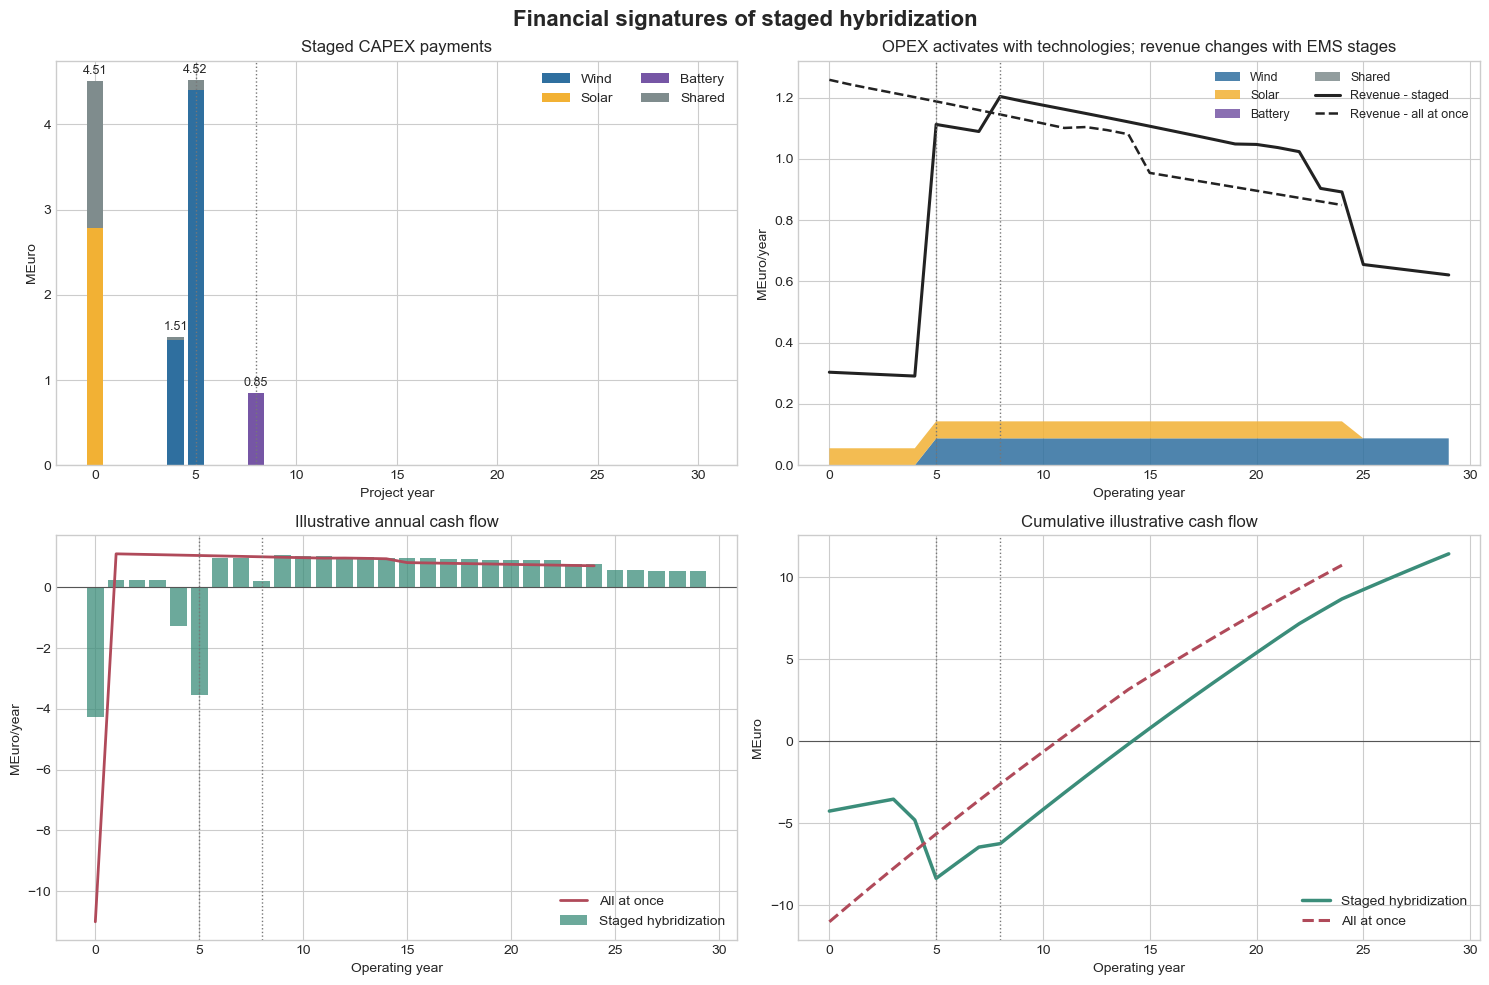

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
ax_capex, ax_opex, ax_cash, ax_cumulative = axes.ravel()

bottom = np.zeros(len(hybrid_capex))
for technology in TECH_COLORS:
    values = hybrid_capex[technology].to_numpy()
    ax_capex.bar(hybrid_capex.index, values, bottom=bottom,
                 color=TECH_COLORS[technology], label=technology.title())
    bottom += values
for year, total in enumerate(bottom):
    if total > 0:
        ax_capex.annotate(f"{total:.2f}", (year, total), xytext=(0, 5),
                          textcoords="offset points", ha="center", fontsize=9)
ax_capex.set(title="Staged CAPEX payments", ylabel="MEuro", xlabel="Project year")
ax_capex.legend(ncols=2, frameon=False)

years = hybrid_opex.index.to_numpy()
ax_opex.stackplot(
    years, *[hybrid_opex[name] for name in TECH_COLORS],
    labels=[name.title() for name in TECH_COLORS],
    colors=[TECH_COLORS[name] for name in TECH_COLORS], alpha=0.85,
)
ax_opex.plot(hybrid_annual.index, hybrid_annual.revenue, color="#222222", linewidth=2.2,
             label="Revenue - staged")
ax_opex.plot(baseline_annual.index, baseline_annual.revenue, color="#222222",
             linewidth=1.8, linestyle="--", label="Revenue - all at once")
ax_opex.set(title="OPEX activates with technologies; revenue changes with EMS stages",
            ylabel="MEuro/year", xlabel="Operating year")
ax_opex.legend(ncols=2, frameon=False, fontsize=9)

ax_cash.axhline(0, color="#555555", linewidth=0.8)
ax_cash.bar(hybrid_annual.index, hybrid_annual.cash_flow, color="#3b8d7a", alpha=0.75,
            label="Staged hybridization")
ax_cash.plot(baseline_annual.index, baseline_annual.cash_flow, color="#b04a5a",
             linewidth=2, label="All at once")
ax_cash.set(title="Illustrative annual cash flow", ylabel="MEuro/year",
            xlabel="Operating year")
ax_cash.legend(frameon=False)

ax_cumulative.axhline(0, color="#555555", linewidth=0.8)
ax_cumulative.plot(hybrid_annual.index, hybrid_annual.cumulative_cash_flow,
                   color="#3b8d7a", linewidth=2.5, label="Staged hybridization")
ax_cumulative.plot(baseline_annual.index, baseline_annual.cumulative_cash_flow,
                   color="#b04a5a", linewidth=2.2, linestyle="--", label="All at once")
ax_cumulative.set(title="Cumulative illustrative cash flow", ylabel="MEuro",
                  xlabel="Operating year")
ax_cumulative.legend(frameon=False)

for ax in axes.ravel():
    for deployment_year in (5, 8):
        ax.axvline(deployment_year, color="#777777", linestyle=":", linewidth=1)

fig.suptitle("Financial signatures of staged hybridization", fontsize=16, fontweight="bold")
fig.tight_layout()
plt.show()

## EMS consequences of staged deployment

Before year 5, only the solar representative year is repeated. A new EMS representative year is used from year 5 when wind is added, and another is used from year 8 when battery operation becomes available. Consequently battery throughput must be exactly zero before year 8.

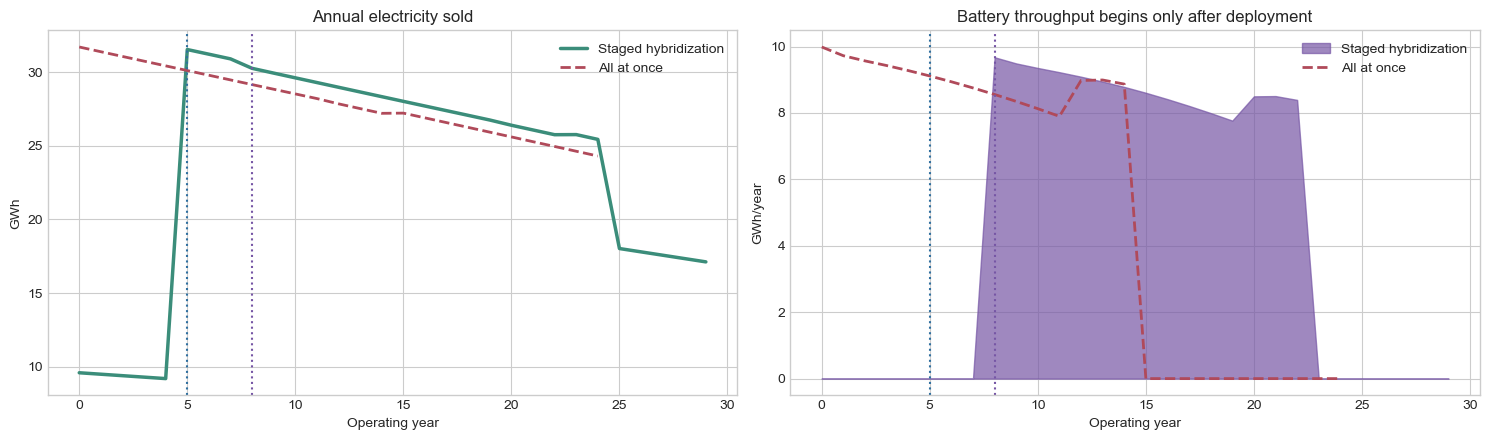

In [11]:
fig, (ax_energy, ax_battery) = plt.subplots(1, 2, figsize=(15, 4.5))

ax_energy.plot(hybrid_annual.index, hybrid_annual.energy_sold_GWh,
               color="#3b8d7a", linewidth=2.5, label="Staged hybridization")
ax_energy.plot(baseline_annual.index, baseline_annual.energy_sold_GWh,
               color="#b04a5a", linewidth=2, linestyle="--", label="All at once")
ax_energy.set(title="Annual electricity sold", xlabel="Operating year", ylabel="GWh")
ax_energy.legend(frameon=False)

ax_battery.fill_between(
    hybrid_annual.index, hybrid_annual.battery_throughput_GWh,
    color=TECH_COLORS["battery"], alpha=0.7, label="Staged hybridization",
)
ax_battery.plot(baseline_annual.index, baseline_annual.battery_throughput_GWh,
                color="#b04a5a", linewidth=2, linestyle="--", label="All at once")
ax_battery.set(title="Battery throughput begins only after deployment",
               xlabel="Operating year", ylabel="GWh/year")
ax_battery.legend(frameon=False)

for ax in (ax_energy, ax_battery):
    ax.axvline(5, color=TECH_COLORS["wind"], linestyle=":", label="Wind deployment")
    ax.axvline(8, color=TECH_COLORS["battery"], linestyle=":", label="Battery deployment")

fig.tight_layout()
plt.show()

assert np.allclose(hybrid_annual.loc[:7, "battery_throughput_GWh"], 0)

### What is specific to the hybridization case?

- The active technology set changes twice, so three distinct EMS representative years are solved and concatenated.
- OPEX and degradation begin at each technology's commissioning and stop at its retirement.
- Shared CAPEX may have a later increment when an add-on increases the maximum land footprint.
- Revenue, battery throughput, annual cash flow, and the project horizon therefore differ from the all-at-once case.